# 可选实验 - ReLU 激活函数

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
plt.style.use('./deeplearning.mplstyle')
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LeakyReLU
from tensorflow.keras.activations import linear, relu, sigmoid
%matplotlib widget
from matplotlib.widgets import Slider
from lab_utils_common import dlc
from autils import plt_act_trio
from lab_utils_relu import *
import warnings
warnings.simplefilter(action='ignore', category=UserWarning)


I0000 00:00:1781450245.607210   47605 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781450245.653936   47605 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781450246.896383   47605 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


<a name="2"></a>
## 2 - ReLU 激活函数
本周介绍了一种新的激活函数，修正线性单元（ReLU）。 
$$ a = max(0,z) \quad\quad\text {\# ReLU 函数} $$

W0000 00:00:1781450248.392152   47605 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


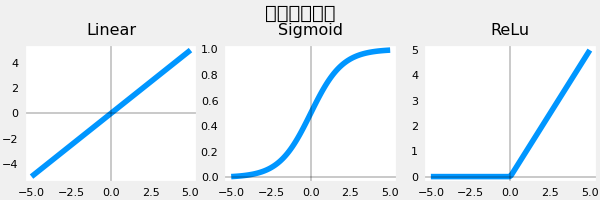

In [2]:
plt_act_trio()

<img align="right" src="./images/C2_W2_ReLu.png"     style=" width:380px; padding: 10px 20px; " >
右边讲座中的示例展示了ReLU的应用。在这个例子中，派生的"感知"特征不是二值的，而是具有连续的值范围。sigmoid最适合开/关或二值情况。ReLU提供连续的线性关系。此外，它还有一个输出为零的'关闭'范围。     
"关闭"特性使ReLU成为非线性激活函数。为什么需要这个？让我们在下面研究一下。

### 为什么需要非线性激活函数？  
<img align="left" src="./images/C2_W2_ReLU_Graph.png"     style=" width:250px; padding: 10px 20px; " > 所示函数由线性片段组成（分段线性）。斜率在线性部分保持一致，然后在过渡点突然改变。在过渡点，添加一个新的线性函数，当添加到现有函数时，将产生新的斜率。新函数在过渡点添加，但在该点之前对输出没有贡献。非线性激活函数负责在过渡点之前（有时之后）禁用输入。以下练习提供了一个更具体的例子。

本练习将在回归问题中使用下面的网络，你需要建模一个分段线性目标：
<img align="center" src="./images/C2_W2_ReLU_Network.png"     style=" width:650px; padding: 10px 20px; ">  
该网络在第一层有3个单元。每个单元都需要形成目标。单元0是预编程的，固定用于映射第一段。你将修改单元1和2中的权重和偏差来建模第2段和第3段。输出单元也是固定的，只是简单地将第一层的输出相加。  

使用下面的滑块，修改权重和偏差以匹配目标。 
提示：从 `w1` 和 `b1` 开始，在匹配第2段之前将 `w2` 和 `b2` 保持为零。点击而不是滑动会更快。如果你遇到困难，不用担心，下面的文本将更详细地描述这一点。

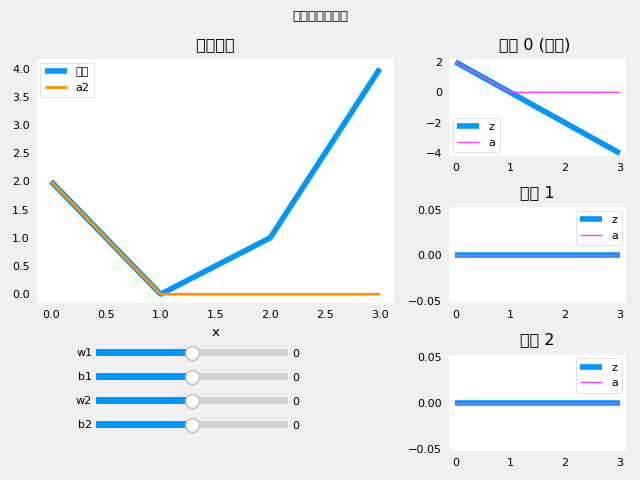

In [3]:
_ = plt_relu_ex()

 
本练习的目标是理解ReLU的非线性行为如何提供所需的能力，即在需要之前关闭函数。让我们看看在这个例子中这是如何工作的。
<img align="right" src="./images/C2_W2_ReLU_Plot.png"     style=" width:600px; padding: 10px 20px; "> 
右边的图包含了第一层单元的输出。   
从顶部开始，单元0负责标记为1的第一段。显示了线性函数 $z$ 和ReLU之后的函数 $a$。你可以看到ReLU在区间 [0,1] 之后截断了函数。这很重要，因为它防止单元0干扰后续段。 

单元1负责第2段。这里ReLU使该单元在x为1之前保持安静。由于第一个单元没有贡献，单元1的斜率 $w^{[1]}_1$ 就是目标线的斜率。必须调整偏差以在x达到1之前保持输出为负。注意单元1的贡献也延伸到第3段。

单元2负责第3段。ReLU再次将输出清零，直到x达到正确的值。单元的斜率 $w^{[1]}_2$ 必须设置为使单元1和2的总和具有所需的斜率。再次调整偏差以在x达到2之前保持输出为负。 

ReLU激活函数的"关闭"或禁用特性使模型能够将线性片段拼接在一起以建模复杂的非线性函数。


## 恭喜！
你现在更熟悉ReLU及其非线性行为的重要性了。